In [1]:
import joblib 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
scaler = joblib.load(r'D:\# coding\PYTHON\Society Projects\Team task\standard_scaler.pkl')
df = joblib.load(r'D:\# coding\PYTHON\Society Projects\Team task\cleaned_dataset.pkl')

In [3]:
x = df.iloc[:,1:33]

In [4]:
x.columns

Index(['python', 'java', 'c_cpp', 'javascript', 'typescript', 'html_css',
       'react', 'angular_vue', 'nodejs', 'fastapi_flask', 'django', 'sql',
       'nosql', 'mongodb', 'postgresql', 'pandas_numpy', 'scikit_learn',
       'deep_learning', 'pytorch_tensorflow', 'nlp', 'computer_vision',
       'docker', 'kubernetes', 'git', 'linux', 'aws', 'azure_gcp', 'ci_cd',
       'terraform', 'cybersecurity_basics', 'penetration_testing',
       'flutter_react_native'],
      dtype='object')

In [5]:
y = df.iloc[:,33]

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [7]:
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [8]:
lr=LogisticRegression(max_iter=1000)
lr.fit(x_train_scaled,y_train)
lr_pred=lr.predict(x_test_scaled)

In [9]:
print("Accuracy:",accuracy_score(y_test,lr_pred))
print("Precision:",precision_score(y_test,lr_pred,average="weighted"))
print("Recall:",recall_score(y_test,lr_pred,average="weighted"))
print("F1 Score:",f1_score(y_test,lr_pred,average="weighted"))

Accuracy: 0.8571428571428571
Precision: 0.8632751557378445
Recall: 0.8571428571428571
F1 Score: 0.8576115309635006


In [10]:
dt=DecisionTreeClassifier(random_state=42)
dt.fit(x_train_scaled,y_train)
dt_pred=dt.predict(x_test_scaled)

In [11]:
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred, average="weighted"))
print("Recall:", recall_score(y_test, dt_pred, average="weighted"))
print("F1 Score:", f1_score(y_test, dt_pred, average="weighted"))

Accuracy: 0.6714285714285714
Precision: 0.6877304016132063
Recall: 0.6714285714285714
F1 Score: 0.6714990202176294


In [12]:
rf=RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train_scaled,y_train)
rf_pred=rf.predict(x_test_scaled)

In [13]:
print("Accuracy:",accuracy_score(y_test,rf_pred))
print("Precision:",precision_score(y_test,rf_pred,average="weighted"))
print("Recall:",recall_score(y_test,rf_pred,average="weighted"))
print("F1 Score:",f1_score(y_test,rf_pred,average="weighted"))

Accuracy: 0.8428571428571429
Precision: 0.8532704808774659
Recall: 0.8428571428571429
F1 Score: 0.8426500093308545


In [14]:
models={
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}
for name, pred in models.items():
    print("\n",name)
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred, average="weighted"))
    print("Recall:", recall_score(y_test, pred, average="weighted"))
    print("F1 Score:", f1_score(y_test, pred, average="weighted"))


 Logistic Regression
Accuracy: 0.8571428571428571
Precision: 0.8632751557378445
Recall: 0.8571428571428571
F1 Score: 0.8576115309635006

 Decision Tree
Accuracy: 0.6714285714285714
Precision: 0.6877304016132063
Recall: 0.6714285714285714
F1 Score: 0.6714990202176294

 Random Forest
Accuracy: 0.8428571428571429
Precision: 0.8532704808774659
Recall: 0.8428571428571429
F1 Score: 0.8426500093308545


In [15]:
models={
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

In [16]:
results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred, average="weighted"),
        precision_score(y_test, dt_pred, average="weighted"),
        precision_score(y_test, rf_pred, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, lr_pred, average="weighted"),
        recall_score(y_test, dt_pred, average="weighted"),
        recall_score(y_test, rf_pred, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred, average="weighted"),
        f1_score(y_test, dt_pred, average="weighted"),
        f1_score(y_test, rf_pred, average="weighted")
    ]
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.857143,0.863275,0.857143,0.857612
1,Decision Tree,0.671429,0.687730,0.671429,0.671499
2,Random Forest,0.842857,0.853270,0.842857,0.842650


In [17]:
best_model = results_df.loc[results_df["F1 Score"].idxmax()]
print(best_model)

Model        Logistic Regression
Accuracy                0.857143
Precision               0.863275
Recall                  0.857143
F1 Score                0.857612
Name: 0, dtype: object


In [18]:
import matplotlib.pyplot as plt

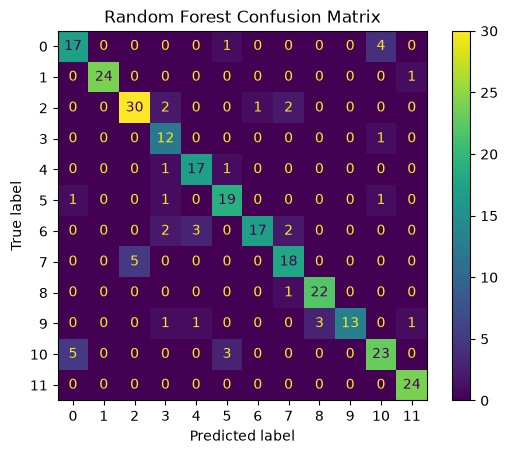

In [19]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

cm=confusion_matrix(y_test,rf_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

### Hyperparameter Tuning


#

In [20]:
from sklearn.model_selection import GridSearchCV

In [21]:
params = {
    "n_estimators": [100, 200,300,400],
    "max_depth": [None,1,2,5,10],
    "min_samples_split": [1,2,4, 5],
    "min_samples_leaf": [1, 2,3,4,5]
}

In [22]:
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

In [23]:
grid.fit(x_train_scaled, y_train)

c:\Users\anshu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
500 fits failed out of a total of 2000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
500 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\anshu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\anshu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 1, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [1, 2, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,400


In [24]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 400}


In [25]:
print("Best CV F1 Score:", grid.best_score_)

Best CV F1 Score: 0.8815718588877679


In [26]:
best_rf = grid.best_estimator_

In [27]:
best_rf_pred = best_rf.predict(x_test_scaled)

In [28]:
print("Tuned Random Forest")
print("Accuracy:", accuracy_score(y_test, best_rf_pred))
print("Precision:", precision_score(y_test, best_rf_pred, average="weighted"))
print("Recall:", recall_score(y_test, best_rf_pred, average="weighted"))
print("F1 Score:", f1_score(y_test, best_rf_pred, average="weighted"))

Tuned Random Forest
Accuracy: 0.8607142857142858
Precision: 0.866983143257303
Recall: 0.8607142857142858
F1 Score: 0.8602021799516667


In [29]:
print("Original Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred, average="weighted"))

print("\nTuned Random Forest")
print("Accuracy:", accuracy_score(y_test, best_rf_pred))
print("F1 Score:", f1_score(y_test, best_rf_pred, average="weighted"))

Original Random Forest
Accuracy: 0.8428571428571429
F1 Score: 0.8426500093308545

Tuned Random Forest
Accuracy: 0.8607142857142858
F1 Score: 0.8602021799516667


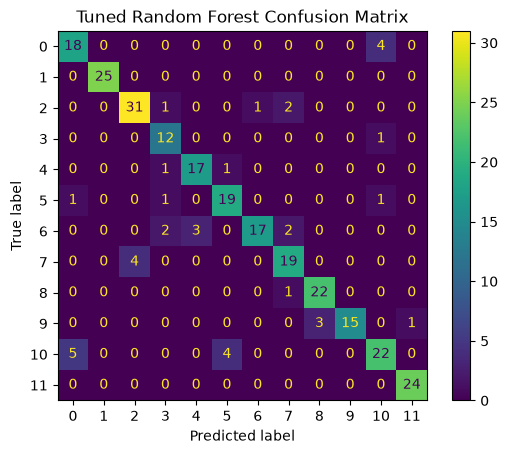

In [30]:
cm = confusion_matrix(y_test, best_rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Tuned Random Forest Confusion Matrix")
plt.show()

In [31]:
from sklearn.metrics import classification_report
print(classification_report(y_test, best_rf_pred))

                           precision    recall  f1-score   support

              AI Engineer       0.75      0.82      0.78        22
        Backend Developer       1.00      1.00      1.00        25
          Cloud Architect       0.89      0.89      0.89        35
    Cybersecurity Analyst       0.71      0.92      0.80        13
             Data Analyst       0.85      0.89      0.87        19
           Data Scientist       0.79      0.86      0.83        22
   Database Administrator       0.94      0.71      0.81        24
          DevOps Engineer       0.79      0.83      0.81        23
       Frontend Developer       0.88      0.96      0.92        23
     Full Stack Developer       1.00      0.79      0.88        19
Machine Learning Engineer       0.79      0.71      0.75        31
     Mobile App Developer       0.96      1.00      0.98        24

                 accuracy                           0.86       280
                macro avg       0.86      0.86      0.86    

In [32]:
joblib.dump(best_rf, r'D:\# coding\PYTHON\Society Projects\Team task\supervised_model.pkl')

['D:\\# coding\\PYTHON\\Society Projects\\Team task\\supervised_model.pkl']

In [33]:
results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, best_rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred, average="weighted"),
        precision_score(y_test, dt_pred, average="weighted"),
        precision_score(y_test, rf_pred, average="weighted"),
        precision_score(y_test, best_rf_pred, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, lr_pred, average="weighted"),
        recall_score(y_test, dt_pred, average="weighted"),
        recall_score(y_test, rf_pred, average="weighted"),
        recall_score(y_test, best_rf_pred, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred, average="weighted"),
        f1_score(y_test, dt_pred, average="weighted"),
        f1_score(y_test, rf_pred, average="weighted"),
        f1_score(y_test, best_rf_pred, average="weighted")
    ]
}

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.857143,0.863275,0.857143,0.857612
1,Decision Tree,0.671429,0.687730,0.671429,0.671499
2,Random Forest,0.842857,0.853270,0.842857,0.842650
3,Tuned Random Forest,0.860714,0.866983,0.860714,0.860202


In [34]:
best_model = results_df.loc[results_df["F1 Score"].idxmax()]

print("Best Model:", best_model["Model"])
print("F1 Score:", best_model["F1 Score"])

Best Model: Tuned Random Forest
F1 Score: 0.8602021799516667


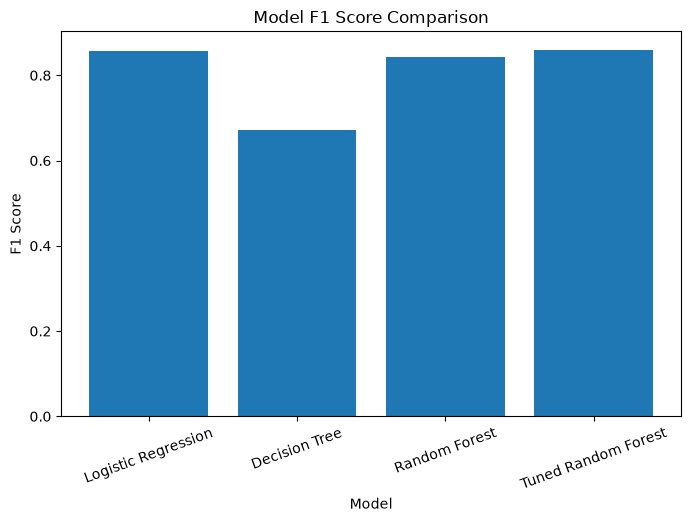

In [35]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["F1 Score"])
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title("Model F1 Score Comparison")
plt.xticks(rotation=20)
plt.show()

In [36]:
print(classification_report(y_test, best_rf_pred))

                           precision    recall  f1-score   support

              AI Engineer       0.75      0.82      0.78        22
        Backend Developer       1.00      1.00      1.00        25
          Cloud Architect       0.89      0.89      0.89        35
    Cybersecurity Analyst       0.71      0.92      0.80        13
             Data Analyst       0.85      0.89      0.87        19
           Data Scientist       0.79      0.86      0.83        22
   Database Administrator       0.94      0.71      0.81        24
          DevOps Engineer       0.79      0.83      0.81        23
       Frontend Developer       0.88      0.96      0.92        23
     Full Stack Developer       1.00      0.79      0.88        19
Machine Learning Engineer       0.79      0.71      0.75        31
     Mobile App Developer       0.96      1.00      0.98        24

                 accuracy                           0.86       280
                macro avg       0.86      0.86      0.86    

In [37]:
loaded_model = joblib.load(r'D:\# coding\PYTHON\Society Projects\Team task\supervised_model.pkl')
test_prediction = loaded_model.predict(x_test_scaled[:5])
print(test_prediction)

['Data Analyst' 'Cloud Architect' 'DevOps Engineer'
 'Machine Learning Engineer' 'Cloud Architect']


In [38]:
sample = x_test.iloc[:5]

In [39]:
sample_scaled = scaler.transform(sample)

In [40]:
sample_prediction = best_rf.predict(sample_scaled)
print(sample_prediction)

['Data Analyst' 'Cloud Architect' 'DevOps Engineer'
 'Machine Learning Engineer' 'Cloud Architect']
